# Vehicle Braking System Automation & Simulation

This notebook demonstrates a digital twin simulation of a vehicle braking system.

The project simulates:

• Vehicle braking physics  
• Anti-lock Braking System (ABS) activation  
• CAN bus communication  
• Vehicle telemetry monitoring  
• Automated braking scenario testing  
• Visualization of braking performance

Technologies used:

Python  
Digital Twin Simulation  
CAN Bus Messaging  
Automation Testing Concepts

## System Architecture

The braking simulation follows a layered testing architecture.

Test Scenario

Vehicle Digital Twin Model

Brake Simulation Engine

CAN Bus Communication

Telemetry Monitoring

Data Visualization

In [1]:
!pip install python-can matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.1.1
    Uninstalling wrapt-2.1.1:
      Successfully uninstalled wrapt-2.1.1


## Digital Twin Vehicle Model

A digital twin is a virtual representation of a physical system.

This model simulates:

• Vehicle speed  
• Vehicle mass  
• Brake pressure  
• ABS activation

In [3]:
class VehicleModel:

    def __init__(self):
        self.speed = 100
        self.mass = 1500
        self.abs_active = False
        self.brake_pressure = 0

    def apply_brake(self, pressure, friction):

        self.brake_pressure = pressure

        braking_force = pressure * 30

        deceleration = (braking_force * friction) / self.mass

        self.speed = max(self.speed - deceleration * 10, 0)

        if pressure > 80:
            self.abs_active = True

## Road Condition Simulation

Different road surfaces affect braking efficiency.

Dry road → high friction  
Wet road → medium friction  
Snow road → low friction

In [4]:
road_conditions = {
    "dry": 1.0,
    "wet": 0.7,
    "snow": 0.4
}

road_type = "wet"

friction = road_conditions[road_type]

## Brake Simulation Test

This test simulates emergency braking at high pressure.

In [5]:
vehicle = VehicleModel()

initial_speed = vehicle.speed

vehicle.apply_brake(90, friction)

print("Initial Speed:", initial_speed)
print("Final Speed:", vehicle.speed)
print("Brake Pressure:", vehicle.brake_pressure)
print("ABS Activated:", vehicle.abs_active)

Initial Speed: 100
Final Speed: 87.4
Brake Pressure: 90
ABS Activated: True


## CAN Bus Message Simulation

Vehicle Electronic Control Units communicate through the CAN bus.

This simulation sends vehicle telemetry data through a virtual CAN message.

In [6]:
import can

bus = can.interface.Bus(channel="virtual", bustype="virtual")

message = can.Message(
    arbitration_id=0x101,
    data=[int(vehicle.speed), vehicle.brake_pressure, int(vehicle.abs_active)],
    is_extended_id=False
)

bus.send(message)

print("CAN Message Sent:", message)

CAN Message Sent: Timestamp:        0.000000    ID:      101    S Rx                DL:  3    57 5a 01


/tmp/ipykernel_148/708571647.py:3: DeprecationWarning: The 'bustype' argument is deprecated since python-can v4.2.0, and scheduled for removal in python-can v5.0.0. Use 'interface' instead.
  bus = can.interface.Bus(channel="virtual", bustype="virtual")


## Vehicle Telemetry Monitoring

Telemetry systems track real-time vehicle performance.

In [7]:
import time

telemetry_data = {
    "speed": vehicle.speed,
    "brake_pressure": vehicle.brake_pressure,
    "abs_status": vehicle.abs_active,
    "timestamp": time.time()
}

print("Telemetry Data:", telemetry_data)

Telemetry Data: {'speed': 87.4, 'brake_pressure': 90, 'abs_status': True, 'timestamp': 1773217179.9399493}


In [ ]:
## Braking Performance Visualization

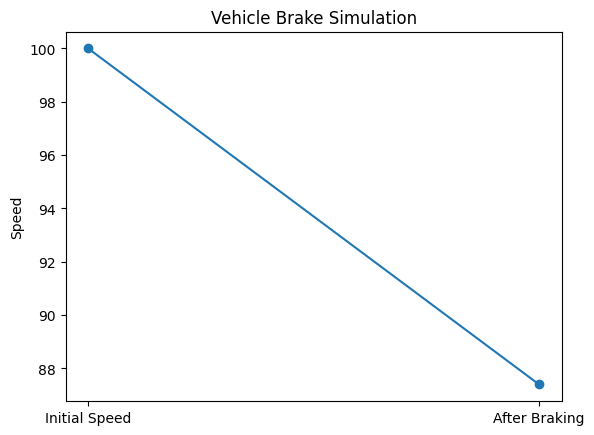

In [8]:
import matplotlib.pyplot as plt

speeds = [initial_speed, vehicle.speed]

plt.figure()

plt.plot(["Initial Speed", "After Braking"], speeds, marker='o')

plt.title("Vehicle Brake Simulation")

plt.ylabel("Speed")

plt.show()

## Automated Brake Scenario Testing

Multiple braking scenarios are tested automatically.

In [9]:
scenarios = [
    {"pressure":50, "road":"dry"},
    {"pressure":90, "road":"wet"},
    {"pressure":100, "road":"snow"}
]

results = []

for s in scenarios:

    v = VehicleModel()

    friction = road_conditions[s["road"]]

    v.apply_brake(s["pressure"], friction)

    results.append(v.speed)

print(results)

[90.0, 87.4, 92.0]


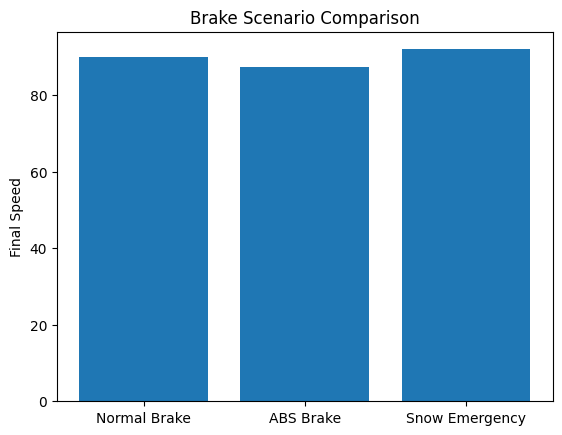

In [10]:
labels = ["Normal Brake", "ABS Brake", "Snow Emergency"]

plt.figure()

plt.bar(labels, results)

plt.title("Brake Scenario Comparison")

plt.ylabel("Final Speed")

plt.show()

## Conclusion

This demonstrates a digital twin simulation of an automotive braking system.

Key features implemented:

• Vehicle physics simulation  
• ABS activation logic  
• CAN bus communication  
• Telemetry monitoring  
• Automated braking scenarios  
• Data visualization

This type of simulation helps to test safety-critical systems before deployment in real vehicles.